Dataset:https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
Tutorial: https://youtu.be/R47JAob1xBY?si=xsojIRAg2nlGMrGQ

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/mnist_test.csv")

In [ ]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

<Axes: >

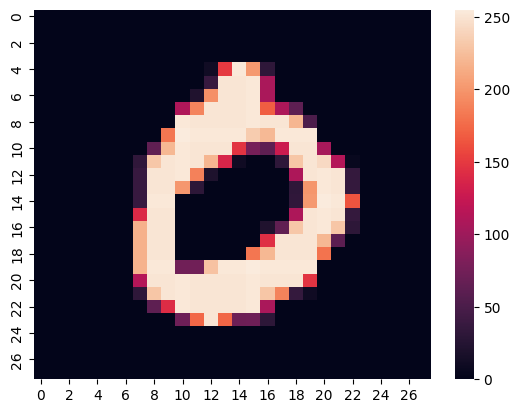

In [ ]:
sns.heatmap(X.iloc[3].values.reshape(28,28))

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9505


In [ ]:
rf.feature_importances_.shape

(784,)

<Axes: >

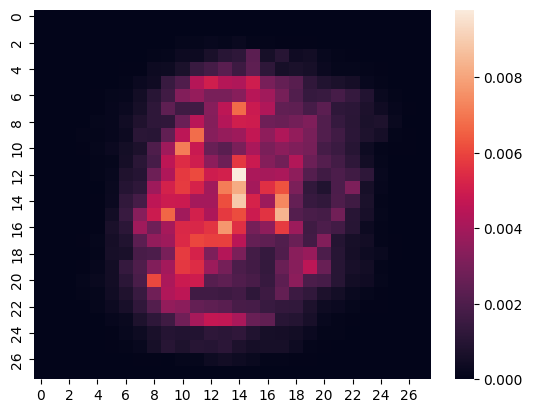

In [ ]:
sns.heatmap(rf.feature_importances_.reshape(28,28))

## How Feature Importance is calculated?   (Decision Tree)

In [42]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

In [43]:
X,y = make_classification(n_samples=5,n_classes=2,n_features=2,n_informative=2,n_redundant=0,random_state=0)

In [44]:
dt = DecisionTreeClassifier()

In [45]:
dt.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.894\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

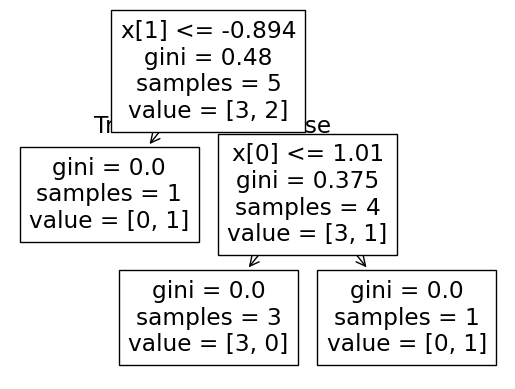

In [46]:
from sklearn.tree import plot_tree
plot_tree(dt)

In [47]:
dt.feature_importances_

array([0.625, 0.375])

In [52]:
## 3 Nodes - 2 columns
X,y = make_classification(n_samples=15,n_classes=2,n_features=2,n_informative=2,n_redundant=0,random_state=0)

In [53]:
dt1 = DecisionTreeClassifier()

In [54]:
dt1.fit(X,y)

DecisionTreeClassifier()

[Text(0.3333333333333333, 0.875, 'x[1] <= -0.383\ngini = 0.498\nsamples = 15\nvalue = [8, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.878\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6666666666666666, 0.375, 'x[0] <= 2.444\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

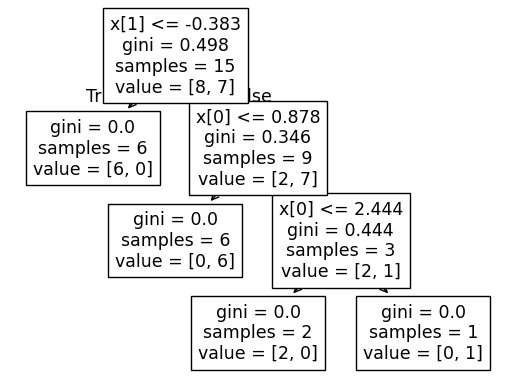

In [55]:
from sklearn.tree import plot_tree
plot_tree(dt1)

In [56]:
dt1.feature_importances_

array([0.41666667, 0.58333333])

## Feature Importance in Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
rf = RandomForestClassifier(n_estimators=2)

In [61]:
rf.fit(X,y)

RandomForestClassifier(n_estimators=2)

In [65]:
rf.feature_importances_

array([0.91071429, 0.08928571])

In [69]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)

[1. 0.]
[0.82142857 0.17857143]


In [71]:
print((0.82142857+1)/2)

0.9107142850000001
